In [2]:
import os

print(os.listdir("/content"))

['.config', 'archive (1).zip', 'sample_data']


In [3]:
import zipfile
import os

zip_path = "/content/archive (1).zip"
extract_path = "/content/diabetes_data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")
print(os.listdir(extract_path))

Dataset extracted successfully!
['diabetic_data.csv', 'description.pdf']


In [4]:
import os

for root, dirs, files in os.walk("/content/diabetes_data"):
    for file in files:
        print(os.path.join(root, file))

/content/diabetes_data/diabetic_data.csv
/content/diabetes_data/description.pdf


In [5]:
import pandas as pd

file_path = "/content/diabetes_data/diabetic_data.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()


Dataset loaded successfully!
Shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [6]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

Number of rows: 101766
Number of columns: 50

Column names:
['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [8]:
df["readmitted"].value_counts()

,count
readmitted,
NO,54864
>30,35545
<30,11357


In [9]:
df["readmitted"].value_counts()

,count
readmitted,
NO,54864
>30,35545
<30,11357


In [10]:
df["readmitted"].value_counts(normalize=True) * 100

,proportion
readmitted,
NO,53.911916
>30,34.928169
<30,11.159916


In [11]:
df["target"] = df["readmitted"].apply(
    lambda x: 1 if x == "<30" else 0
)

print(df["target"].value_counts())
print(df["target"].value_counts(normalize=True) * 100)

target
0    90409
1    11357
Name: count, dtype: int64
target
0    88.840084
1    11.159916
Name: proportion, dtype: float64


In [12]:
# Make a copy so our original dataset remains unchanged
data = df.copy()

# Columns to remove
drop_cols = [
    "encounter_id",
    "patient_nbr",
    "readmitted",
    "weight",
    "max_glu_serum",
    "A1Cresult"
]

data = data.drop(columns=drop_cols)

print("New shape:", data.shape)
print("\nRemaining columns:")
print(data.columns.tolist())

New shape: (101766, 45)

Remaining columns:
['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'target']


In [13]:
missing = data.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

print(missing)

Series([], dtype: int64)


In [14]:
print("Number of '?' values in each column:")

question_marks = (data == "?").sum()

print(question_marks[question_marks > 0].sort_values(ascending=False))

Number of '?' values in each column:
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
dtype: int64


In [15]:
import numpy as np

# Replace '?' with NaN
data = data.replace("?", np.nan)

print("Missing values after replacement:")
print(data.isnull().sum().sort_values(ascending=False).head(10))

Missing values after replacement:
medical_specialty           49949
payer_code                  40256
race                         2273
diag_3                       1423
diag_2                        358
diag_1                         21
discharge_disposition_id        0
time_in_hospital                0
admission_source_id             0
num_lab_procedures              0
dtype: int64


In [16]:
data = data.drop(columns=["medical_specialty", "payer_code"])

print("Shape after removing high-missing columns:", data.shape)

Shape after removing high-missing columns: (101766, 43)


In [17]:
categorical_cols = ["race", "diag_1", "diag_2", "diag_3"]

for col in categorical_cols:
    data[col] = data[col].fillna("Unknown")

print("Remaining missing values:")
print(data.isnull().sum().sum())

Remaining missing values:
0


In [18]:
# Features
X = data.drop(columns=["target"])

# Target
y = data["target"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

X shape: (101766, 42)
y shape: (101766,)

Target distribution:
target
0    90409
1    11357
Name: count, dtype: int64


In [19]:
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical columns:", len(categorical_cols))
print(categorical_cols)

print("\nNumerical columns:", len(numerical_cols))
print(numerical_cols)

Categorical columns: 31
['race', 'gender', 'age', 'diag_1', 'diag_2', 'diag_3', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']

Numerical columns: 11
['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training samples: 81412
Testing samples: 20354

Training target distribution:
target
0    0.888395
1    0.111605
Name: proportion, dtype: float64

Testing target distribution:
target
0    0.888425
1    0.111575
Name: proportion, dtype: float64


In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [22]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        C=1.0,
        solver="liblinear",
        max_iter=1000
    ))
])

print("Logistic Regression model created!")

Logistic Regression model created!


In [23]:
print("Training model...")

model.fit(X_train, y_train)

print("Model training completed!")

Training model...
Model training completed!


In [24]:
print("Training model...")

model.fit(X_train, y_train)

print("Model training completed!")

Training model...
Model training completed!


In [25]:
# Predict the class (0 or 1)
y_pred = model.predict(X_test)

# Predict probability of readmission
y_prob = model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully!")

print("\nFirst 10 predicted classes:")
print(y_pred[:10])

print("\nFirst 10 readmission probabilities:")
print(y_prob[:10])

Predictions generated successfully!

First 10 predicted classes:
[0 0 0 0 0 0 0 0 0 0]

First 10 readmission probabilities:
[0.1357055  0.05955496 0.14203179 0.23955064 0.11849309 0.03289911
 0.05486021 0.06552932 0.24746366 0.18851747]


In [26]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC Score: {roc_auc:.4f}")

ROC-AUC Score: 0.6443


In [27]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")

Confusion Matrix:
[[18038    45]
 [ 2228    43]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18083
           1       0.49      0.02      0.04      2271

    accuracy                           0.89     20354
   macro avg       0.69      0.51      0.49     20354
weighted avg       0.85      0.89      0.84     20354

Precision: 0.4886
Recall:    0.0189
F1 Score:  0.0365


In [28]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

thresholds = [0.50, 0.40, 0.30, 0.20, 0.10, 0.05]

results = []

for threshold in thresholds:
    predictions = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test, predictions
    ).ravel()

    precision = precision_score(
        y_test, predictions, zero_division=0
    )

    recall = recall_score(
        y_test, predictions, zero_division=0
    )

    f1 = f1_score(
        y_test, predictions, zero_division=0
    )

    results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "False Positives": fp,
        "False Negatives": fn,
        "True Positives": tp
    })

threshold_results = pd.DataFrame(results)

threshold_results

,Threshold,Precision,Recall,F1,False Positives,False Negatives,True Positives
0,0.50,0.488636,0.018934,0.036456,45,2228,43
1,0.40,0.449198,0.036988,0.068348,103,2187,84
2,0.30,0.373134,0.077059,0.127737,294,2096,175
3,0.20,0.258393,0.189784,0.218837,1237,1840,431
4,0.10,0.153723,0.631880,0.247286,7900,836,1435
5,0.05,0.118614,0.956847,0.211063,16147,98,2173


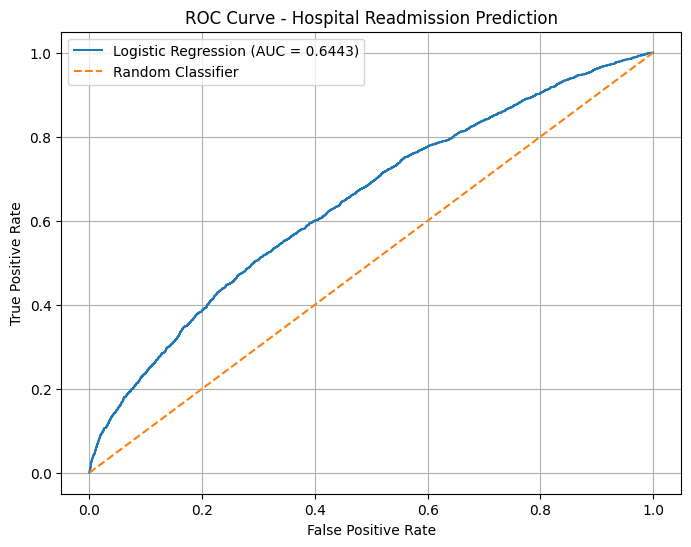

In [29]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc_score:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Hospital Readmission Prediction")
plt.legend()
plt.grid(True)
plt.show()

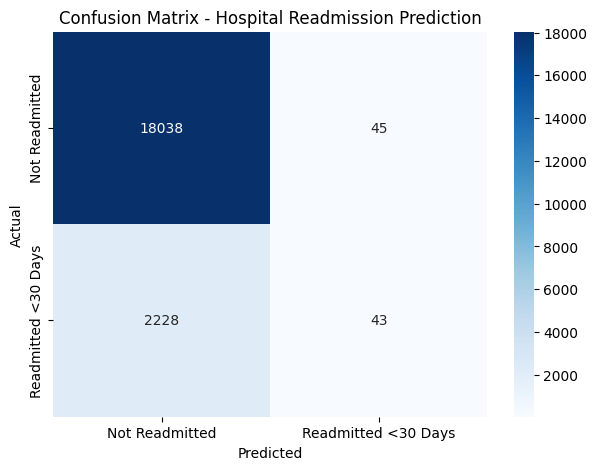

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Readmitted", "Readmitted <30 Days"],
    yticklabels=["Not Readmitted", "Readmitted <30 Days"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Hospital Readmission Prediction")

plt.show()

In [31]:
results_summary = pd.DataFrame({
    "Metric": [
        "ROC-AUC",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Score": [
        roc_auc,
        (y_pred == y_test).mean(),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ]
})

results_summary

,Metric,Score
0,ROC-AUC,0.644274
1,Accuracy,0.888327
2,Precision,0.488636
3,Recall,0.018934
4,F1 Score,0.036456


In [32]:
# Get feature names after preprocessing
feature_names = model.named_steps["preprocessor"].get_feature_names_out()

# Get Logistic Regression coefficients
coefficients = model.named_steps["classifier"].coef_[0]

# Create a dataframe
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Strongest positive associations
positive_features = feature_importance.sort_values(
    "Coefficient", ascending=False
).head(10)

# Strongest negative associations
negative_features = feature_importance.sort_values(
    "Coefficient", ascending=True
).head(10)

print("Top 10 positive coefficients:")
display(positive_features)

print("\nTop 10 negative coefficients:")
display(negative_features)

Top 10 positive coefficients:


,Feature,Coefficient
240,cat__diag_1_356,1.612492
167,cat__diag_1_271,1.572910
1464,cat__diag_3_156,1.508250
719,cat__diag_1_V58,1.465018
1569,cat__diag_3_273,1.419559
469,cat__diag_1_643,1.371148
734,cat__diag_2_136,1.370780
164,cat__diag_1_263,1.338174
2189,cat__diag_3_V60,1.317024
44,cat__diag_1_146,1.313650



Top 10 negative coefficients:


,Feature,Coefficient
1241,cat__diag_2_807,-1.208874
407,cat__diag_1_566,-1.143783
1785,cat__diag_3_537,-1.094976
1217,cat__diag_2_782,-1.053060
1346,cat__diag_2_999,-1.051797
979,cat__diag_2_429,-1.025183
1934,cat__diag_3_736,-1.004139
199,cat__diag_1_304,-0.985893
1792,cat__diag_3_553,-0.977319
301,cat__diag_1_430,-0.950883
